In [4]:
!!pip uninstall numpy scipy shap -y

['Found existing installation: numpy 2.4.4',
 'Uninstalling numpy-2.4.4:',
 '  Successfully uninstalled numpy-2.4.4',
 'Found existing installation: scipy 1.17.1',
 'Uninstalling scipy-1.17.1:',
 '  Successfully uninstalled scipy-1.17.1',
 "WARNING: Failed to remove contents in a temporary directory 'F:\\anaconda3\\envs\\demand-predictor\\Lib\\site-packages\\~cipy.libs'.",
 'You can safely remove it manually.',
 "WARNING: Failed to remove contents in a temporary directory 'F:\\anaconda3\\envs\\demand-predictor\\Lib\\site-packages\\~cipy'.",
 'You can safely remove it manually.',
 'Found existing installation: shap 0.51.0',
 'Uninstalling shap-0.51.0:',
 '  Successfully uninstalled shap-0.51.0']

In [5]:
!pip install numpy==1.26.4 scipy==1.11.4 shap==0.44.1

  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
   ---------------------------------------- 0.0/44.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.1 MB ? eta -:--:--
    --------------------------------------- 0.8/44.1 MB 3.1 MB/s eta 0:00:15
   - -------------------------------------- 1.6/44.1 MB 3.4 MB/s eta 0:00:13
   -- ------------------------------------- 2.4/44.1 MB 3.5 MB/s eta 0:00:12
   -- ------------------------------------- 3.1/44.1 MB 3.6 MB/s eta 0:00:12
   --- ------------------------------------ 4.2/44.1 MB 3.9 MB/s eta 0:00:11
   ---- ----------------------------------- 5.2/44.1 MB 4.1 MB/s eta 0:00:10
   ----- ---------------------------------- 6.3/44.1 MB 4.2 MB/s eta 0:00:09
   ------ --------------------------------- 7.3/44.1 MB 4.4 MB/s eta 0:00:09
   ------- -------------------------------- 8.4/44.1 MB 4.5 MB/s eta 0:00:08
   -------- ----------------------

In [7]:
import sys
!{sys.executable} -m pip install optuna

  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)

   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- -

In [8]:
# ── Cell 1 — imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
import optuna
import pickle
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import mlflow

print("All imports done!")

All imports done!


In [9]:
# ── Cell 2 — load data and model ─────────────────────────────────────
ts_df = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\features_df_fixed.csv')
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])

with open('models/feature_cols.pkl', 'rb') as f:
    FEATURE_COLS = pickle.load(f)

with open('models/lgbm_v1.pkl', 'rb') as f:
    model_v1 = pickle.load(f)

X = ts_df[FEATURE_COLS]
y = ts_df['demand']

cutoff     = ts_df['datetime'].max() - pd.Timedelta(weeks=4)
train_mask = ts_df['datetime'] <= cutoff
val_mask   = ts_df['datetime'] >  cutoff

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print(f"Train : {X_train.shape[0]:,}")
print(f"Val   : {X_val.shape[0]:,}")
print(f"Features: {len(FEATURE_COLS)}")

Train : 1,717,756
Val   : 327,592
Features: 31


In [10]:
# ── Cell 3 — evaluation helper ────────────────────────────────────────
def evaluate(y_true, y_pred, name="model"):
    nonzero = y_true > 0
    y_nz    = np.array(y_true)[nonzero]
    p_nz    = np.array(y_pred)[nonzero]

    mape = np.mean(np.abs((y_nz - p_nz) / y_nz)) * 100
    wape = np.sum(np.abs(y_nz - p_nz)) / np.sum(y_nz) * 100
    rmse = np.sqrt(mean_squared_error(y_nz, p_nz))
    r2   = r2_score(y_nz, p_nz)
    bias = np.mean(p_nz - y_nz)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  WAPE : {wape:.2f}%")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  Bias : {bias:.4f}")
    print(f"{'='*45}")

    return {'model':name,'mape':round(mape,2),'wape':round(wape,2),
            'rmse':round(rmse,2),'r2':round(r2,4),'bias':round(bias,4)}

In [11]:
# ── Cell 4 — use sample for Optuna (speed) ────────────────────────────
# 2M rows x 50 trials would take hours
# sample 30% of training data — still 600k rows, statistically valid

sample_frac  = 0.30
train_sample = X_train.sample(frac=sample_frac, random_state=42)
y_sample     = y_train.loc[train_sample.index]

print(f"Full train size   : {X_train.shape[0]:,}")
print(f"Sample train size : {train_sample.shape[0]:,}")
print(f"Val size          : {X_val.shape[0]:,}")
print("Using sample for Optuna speed — final model trains on full data")

Full train size   : 1,717,756
Sample train size : 515,327
Val size          : 327,592
Using sample for Optuna speed — final model trains on full data


In [12]:
# ── Cell 5 — Optuna objective function ───────────────────────────────
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 4, 12),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 200),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        train_sample, y_sample,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(999)]
    )

    pred    = np.clip(model.predict(X_val), 0, None)
    nonzero = y_val > 0
    y_nz    = y_val[nonzero].values
    p_nz    = pred[nonzero]
    wape    = np.sum(np.abs(y_nz - p_nz)) / np.sum(y_nz) * 100

    return wape  # minimize WAPE

print("Objective function defined")
print("Optimizing WAPE — lower is better")

Objective function defined
Optimizing WAPE — lower is better


In [13]:
# ── Cell 6 — run Optuna (50 trials ~10-15 mins) ───────────────────────
study = optuna.create_study(
    direction  = "minimize",
    study_name = "demand-pulse-lgbm",
    sampler    = optuna.samplers.TPESampler(seed=42)
)

print("Starting Optuna — 50 trials...")
print("Each trial takes ~15-20 seconds. Total ~15 mins.\n")

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest WAPE  : {study.best_value:.2f}%")
print(f"Best params: {study.best_params}")

Starting Optuna — 50 trials...
Each trial takes ~15-20 seconds. Total ~15 mins.



  0%|          | 0/50 [00:00<?, ?it/s]


Best WAPE  : 9.92%
Best params: {'n_estimators': 974, 'learning_rate': 0.015203409285979293, 'max_depth': 12, 'num_leaves': 200, 'min_child_samples': 64, 'subsample': 0.887098392707996, 'colsample_bytree': 0.6885372393945571, 'reg_alpha': 0.5615195711001008, 'reg_lambda': 0.3945277342875057}


In [14]:
# ── Cell 7 — train final model on full data with best params ──────────
best_params = study.best_params
best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

print("Training final model on FULL training data with best params...")
print(f"Params: {best_params}\n")

mlflow.set_experiment("demand-pulse")

with mlflow.start_run(run_name="lgbm_v2_optuna"):
    model_v2 = lgb.LGBMRegressor(**best_params)
    model_v2.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(100)]
    )

    pred_v2   = np.clip(model_v2.predict(X_val), 0, None)
    metrics_v2 = evaluate(y_val.values, pred_v2, "LightGBM v2 (Optuna tuned)")

    mlflow.log_params(best_params)
    mlflow.log_metric("mape", metrics_v2['mape'])
    mlflow.log_metric("wape", metrics_v2['wape'])
    mlflow.log_metric("rmse", metrics_v2['rmse'])
    mlflow.log_metric("r2",   metrics_v2['r2'])
    mlflow.sklearn.log_model(model_v2, "lgbm_v2")

print("Training done!")

Training final model on FULL training data with best params...
Params: {'n_estimators': 974, 'learning_rate': 0.015203409285979293, 'max_depth': 12, 'num_leaves': 200, 'min_child_samples': 64, 'subsample': 0.887098392707996, 'colsample_bytree': 0.6885372393945571, 'reg_alpha': 0.5615195711001008, 'reg_lambda': 0.3945277342875057, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

[100]	valid_0's l2: 457.958
[200]	valid_0's l2: 119.957
[300]	valid_0's l2: 99.1577
[400]	valid_0's l2: 96.8039

  LightGBM v2 (Optuna tuned)
  MAPE : 25.14%
  WAPE : 9.93%
  RMSE : 9.83
  R²   : 0.9860
  Bias : -1.1776
Training done!


In [15]:
# ── Cell 8 — compare v1 vs v2 ─────────────────────────────────────────
pred_v1   = np.clip(model_v1.predict(X_val), 0, None)
metrics_v1 = evaluate(y_val.values, pred_v1, "LightGBM v1 (default)")

results = pd.DataFrame([metrics_v1, metrics_v2])
print("\nComparison:")
print(results[['model','mape','wape','rmse','r2','bias']].to_string(index=False))

improvement = metrics_v1['wape'] - metrics_v2['wape']
print(f"\nOptuna improved WAPE by {improvement:.2f}%")


  LightGBM v1 (default)
  MAPE : 24.56%
  WAPE : 10.22%
  RMSE : 10.11
  R²   : 0.9852
  Bias : -1.4261

Comparison:
                     model  mape  wape  rmse     r2    bias
     LightGBM v1 (default) 24.56 10.22 10.11 0.9852 -1.4261
LightGBM v2 (Optuna tuned) 25.14  9.93  9.83 0.9860 -1.1776

Optuna improved WAPE by 0.29%


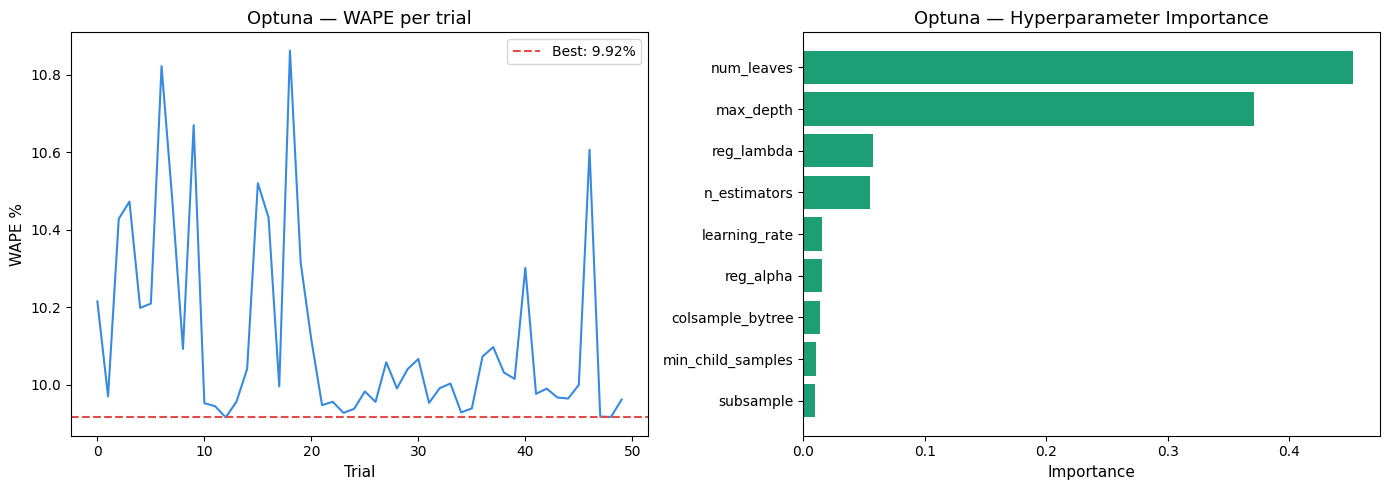

Saved optuna results plot!


In [17]:
# ── Cell 9 — Optuna optimization history plot ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# trial values over time
values = [t.value for t in study.trials]
axes[0].plot(values, color='#378ADD', linewidth=1.5)
axes[0].axhline(y=study.best_value, color='#E24B4A',
                linestyle='--', label=f'Best: {study.best_value:.2f}%')
axes[0].set_title('Optuna — WAPE per trial', fontsize=13)
axes[0].set_xlabel('Trial', fontsize=11)
axes[0].set_ylabel('WAPE %', fontsize=11)
axes[0].legend()

# parameter importance
param_importance = optuna.importance.get_param_importances(study)
params = list(param_importance.keys())
importances = list(param_importance.values())
axes[1].barh(params[::-1], importances[::-1], color='#1D9E75', edgecolor='none')
axes[1].set_title('Optuna — Hyperparameter Importance', fontsize=13)
axes[1].set_xlabel('Importance', fontsize=11)

plt.tight_layout()
plt.savefig('plot_optuna_results.png', dpi=150)
plt.show()
print("Saved optuna results plot!")

In [18]:
# ── Cell 10 — SHAP explainability ────────────────────────────────────
# use 2000 row sample for speed — SHAP is slow on large datasets
print("Computing SHAP values (this takes 2-3 mins)...")

shap_sample = X_val.sample(2000, random_state=42)

explainer   = shap.TreeExplainer(model_v2)
shap_values = explainer.shap_values(shap_sample)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print("Done!")

Computing SHAP values (this takes 2-3 mins)...
SHAP values shape: (2000, 31)
Done!


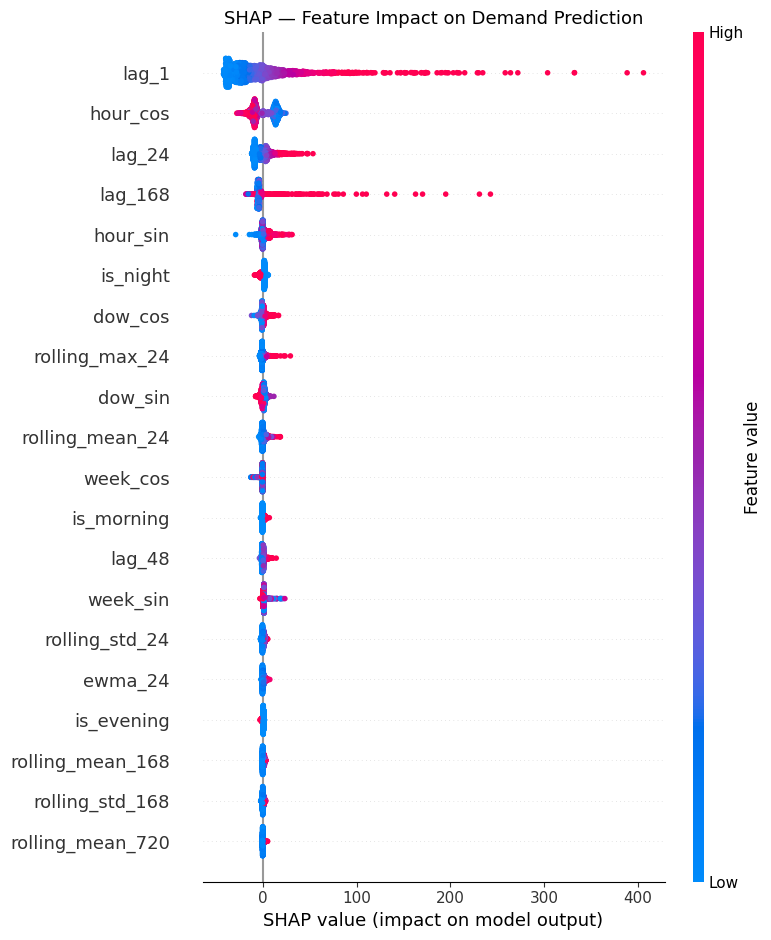

Saved SHAP beeswarm plot — put this in your README!


In [19]:
# ── Cell 11 — SHAP beeswarm plot (most important for CV/README) ───────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, shap_sample,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP — Feature Impact on Demand Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('plot_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved SHAP beeswarm plot — put this in your README!")

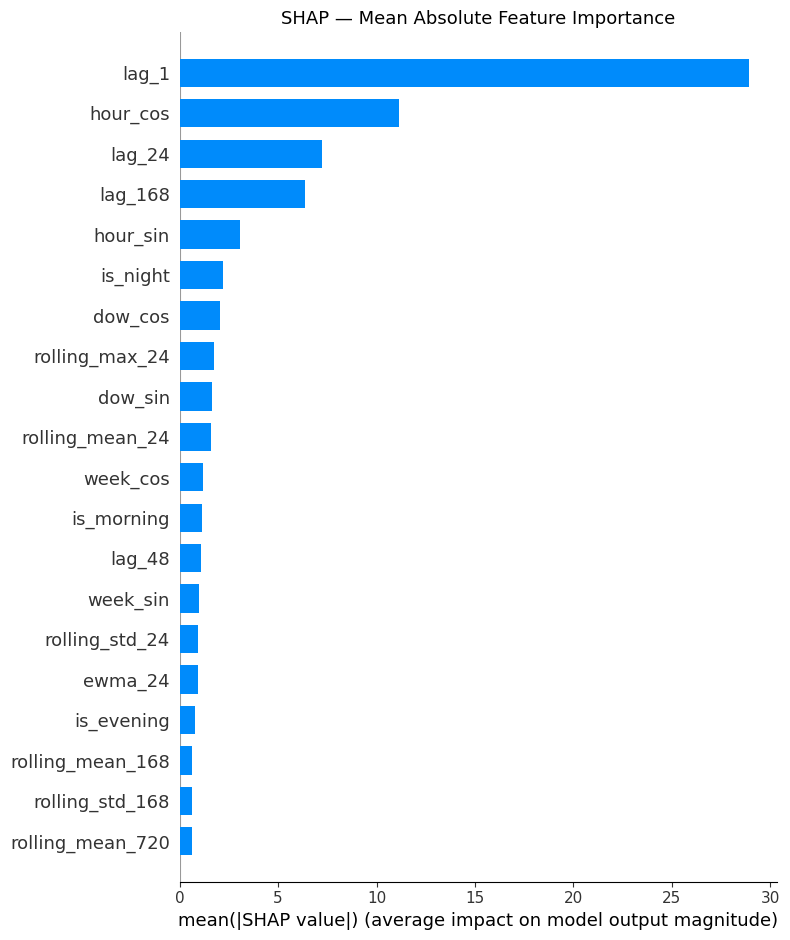

In [20]:
# ── Cell 12 — SHAP bar plot (mean absolute impact) ───────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, shap_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP — Mean Absolute Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig('plot_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

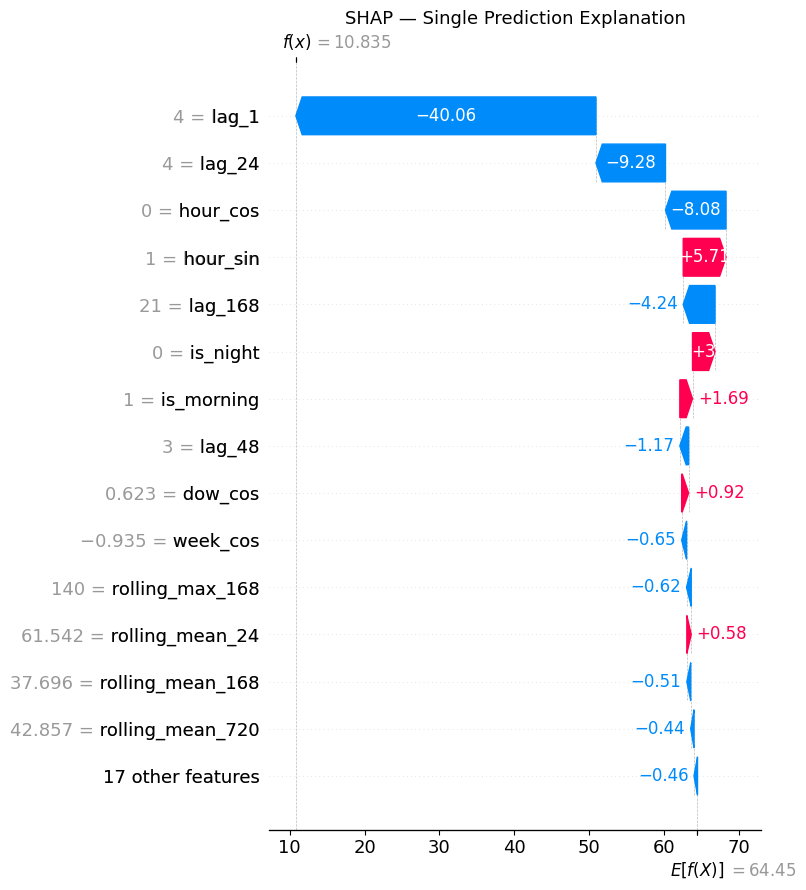

Saved waterfall plot!


In [21]:
# ── Cell 13 — SHAP waterfall for single prediction ────────────────────
# explains one specific prediction — good for demos
shap_explanation = explainer(shap_sample.iloc[:1])

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation[0], max_display=15, show=False)
plt.title('SHAP — Single Prediction Explanation', fontsize=13)
plt.tight_layout()
plt.savefig('plot_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved waterfall plot!")

In [22]:
# ── Cell 14 — error analysis by product ──────────────────────────────
val_df = ts_df[val_mask].copy()
val_df['predicted'] = pred_v2
val_df['error']     = np.abs(val_df['demand'] - val_df['predicted'])
val_df['pct_error'] = val_df['error'] / val_df['demand'].replace(0, np.nan) * 100

product_errors = (val_df.groupby('product_name')
                  .agg(mean_demand=('demand','mean'),
                       mean_error=('pct_error','mean'))
                  .dropna()
                  .sort_values('mean_error')
                  .reset_index())

print("Top 10 best predicted products:")
print(product_errors.head(10).to_string(index=False))
print("\nTop 10 worst predicted products:")
print(product_errors.tail(10).to_string(index=False))

Top 10 best predicted products:
          product_name  mean_demand  mean_error
                Banana   278.474851    9.387514
Bag of Organic Bananas   223.609970    9.571130
  Organic Baby Spinach   142.660810   14.119828
  Organic Hass Avocado   126.113745   14.249840
  Organic Strawberries   156.360233   15.852159
       Organic Avocado   104.404890   19.143220
   Organic Raspberries    81.470888   20.713235
           Large Lemon    90.469180   21.276401
          Strawberries    85.025526   22.048157
   Organic Blueberries    59.761912   22.900586

Top 10 worst predicted products:
                   product_name  mean_demand  mean_error
                    Raspberries    35.854206   28.451018
          Michigan Organic Kale    40.941483   28.772959
                        Carrots    43.775668   28.892752
         100% Whole Wheat Bread    37.863294   29.080506
Organic Unsweetened Almond Milk    35.914684   29.155447
        Organic Red Bell Pepper    35.565272   29.384434
       

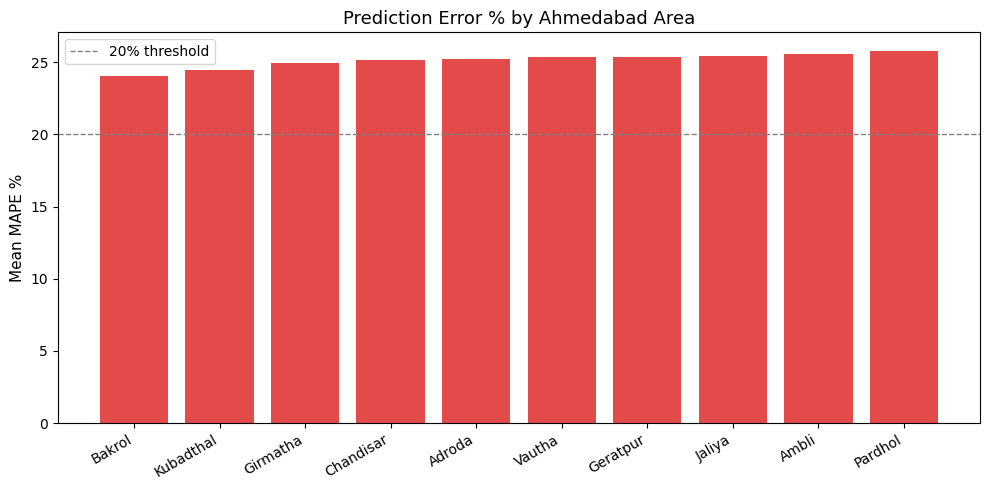


Error by area:
area_name  mean_demand  mean_error
   Bakrol    64.830456   24.056815
Kubadthal    66.035322   24.502928
 Girmatha    65.084742   24.931300
Chandisar    65.190478   25.146006
   Adroda    64.578701   25.246111
   Vautha    65.570024   25.346087
 Geratpur    64.510415   25.370460
   Jaliya    64.752073   25.447089
    Ambli    64.513211   25.598498
  Pardhol    64.736676   25.790039


In [23]:
# ── Cell 15 — error analysis by pincode ──────────────────────────────
pincode_errors = (val_df.groupby('area_name')
                  .agg(mean_demand=('demand','mean'),
                       mean_error=('pct_error','mean'))
                  .dropna()
                  .sort_values('mean_error')
                  .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#1D9E75' if e < 20 else '#E24B4A'
           for e in pincode_errors['mean_error']]
ax.bar(pincode_errors['area_name'],
       pincode_errors['mean_error'],
       color=colors, edgecolor='none')
ax.axhline(y=20, color='gray', linestyle='--',
           linewidth=1, label='20% threshold')
ax.set_title('Prediction Error % by Ahmedabad Area', fontsize=13)
ax.set_ylabel('Mean MAPE %', fontsize=11)
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plot_error_by_pincode.png', dpi=150)
plt.show()

print("\nError by area:")
print(pincode_errors.to_string(index=False))

In [24]:
# ── Cell 16 — save best model and results ────────────────────────────
with open('models/lgbm_best.pkl', 'wb') as f:
    pickle.dump(model_v2, f)

with open('models/feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

final_results = pd.DataFrame([metrics_v1, metrics_v2])
final_results.to_csv(r'F:\projectss\personal\blinkit_project\data\processed/model_results_final.csv', index=False)

print("Saved:")
print("  models/lgbm_best.pkl       ← use this for deployment")
print("  models/feature_cols.pkl")
print("  data/processed/model_results_final.csv")
print("\nNotebook 04 complete — ready for deployment!")

Saved:
  models/lgbm_best.pkl       ← use this for deployment
  models/feature_cols.pkl
  data/processed/model_results_final.csv

Notebook 04 complete — ready for deployment!
